# Data briefing - Exhibit 4: Realised market prices

**Files:** `day_ahead_prices.csv` (realised 2024 DE/LU Day-Ahead) and `imbalance_prices.csv`
(realised 2024 quality-assured symmetric German reBAP).

*All reported numbers are rounded to two decimal places.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
DATA = "../../data"

da = pd.read_csv(f"{DATA}/day_ahead_prices.csv")
im = pd.read_csv(f"{DATA}/imbalance_prices.csv")
for df in (da, im):
    df["t"] = pd.to_datetime(df["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

DAP, IMP = "day_ahead_price_eur_mwh", "imbalance_price_eur_mwh"
m = da[["timestamp_utc", "t", DAP]].merge(im[["timestamp_utc", IMP]], on="timestamp_utc")
m["spread"] = m[IMP] - m[DAP]

print("rows:", len(da), len(im), "| missing:", int(da[DAP].isna().sum()), int(im[IMP].isna().sum()))
summary = pd.DataFrame({
    "Day-Ahead": da[DAP].describe(),
    "reBAP":     im[IMP].describe(),
}).T
summary["IQR"] = [da[DAP].quantile(.75) - da[DAP].quantile(.25), im[IMP].quantile(.75) - im[IMP].quantile(.25)]
summary.round(2)

rows: 35136 35136 | missing: 0 0


,count,mean,std,min,25%,50%,75%,max,IQR
Day-Ahead,"35,136.00",78.51,52.72,-135.45,55.56,79.59,101.34,936.28,45.78
reBAP,"35,136.00",85.77,282.66,"-5,734.46",17.16,89.96,135.62,"14,999.99",118.47


## 1. Time series

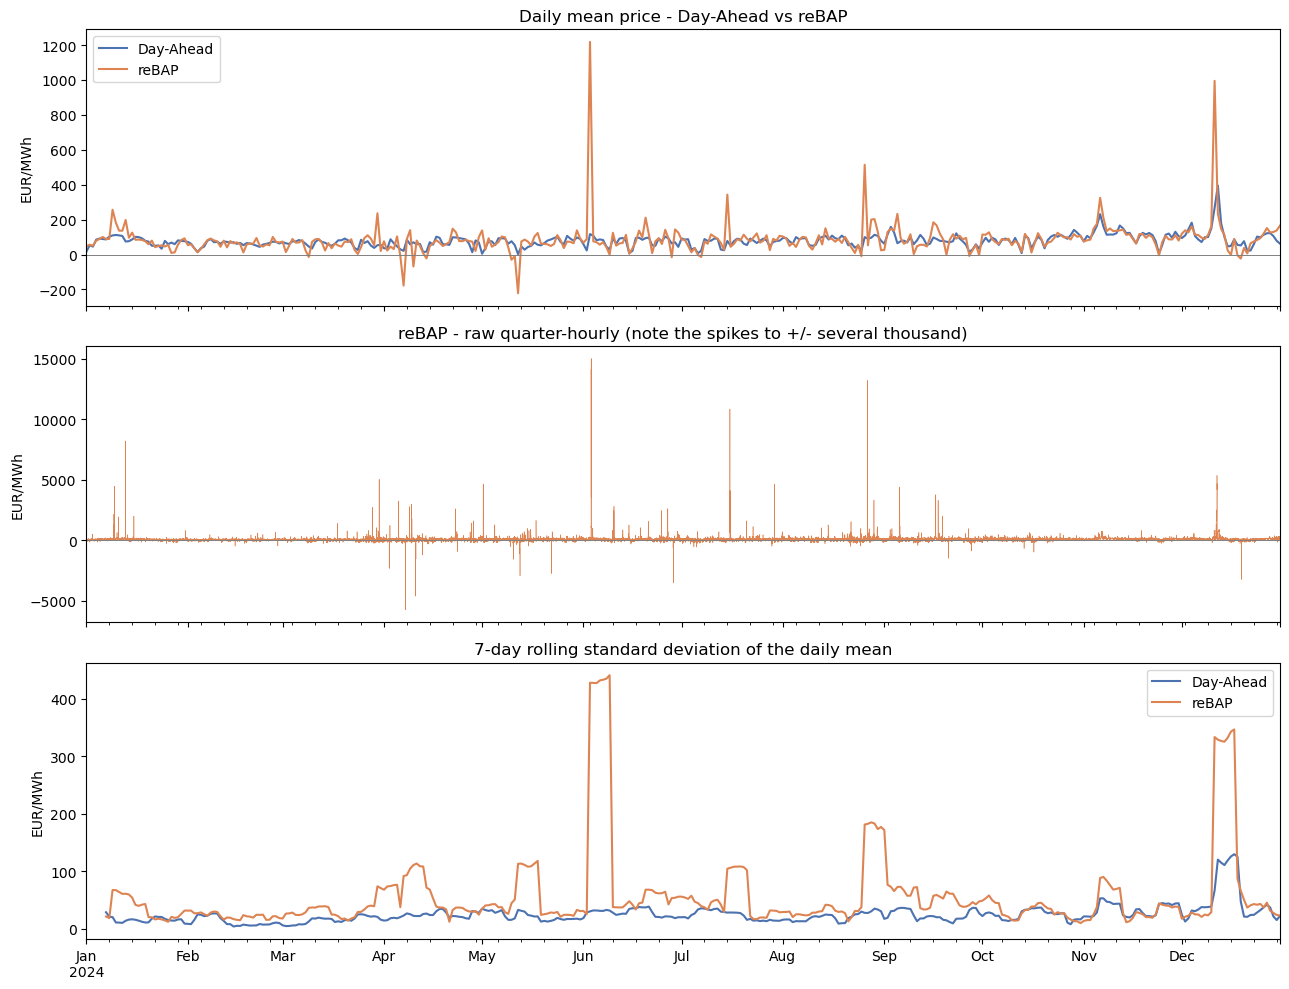

DA daily-mean 7d rolling std: max 129.85 around 2024-12-17
reBAP daily-mean 7d rolling std: max 441.31 around 2024-06-09

monthly mean / std:
    DA_mean  DA_std  reBAP_mean  reBAP_std
t                                         
1     76.57   29.20       87.01     199.37
2     61.34   21.29       60.41      66.55
3     64.70   26.29       63.50     160.95
4     62.36   41.39       52.97     239.03
5     67.21   44.87       60.87     200.87
6     72.89   47.72      116.86     644.19
7     67.70   46.21       79.41     266.46
8     82.05   49.60       93.38     380.34
9     78.31   54.06       84.20     198.12
10    86.10   42.93       86.06      93.60
11   113.91   64.92      115.03      93.16
12   108.32   92.04      128.72     315.18


In [2]:
dd = pd.DataFrame({
    "Day-Ahead": da.groupby(da.t.dt.date)[DAP].mean(),
    "reBAP":     im.groupby(im.t.dt.date)[IMP].mean(),
})
dd.index = pd.to_datetime(dd.index)

fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
dd.plot(ax=ax[0], color=["#4C72B0", "#DD8452"])
ax[0].axhline(0, color="grey", lw=.7); ax[0].set_ylabel("EUR/MWh")
ax[0].set_title("Daily mean price - Day-Ahead vs reBAP")

ax[1].plot(im.t, im[IMP], color="#DD8452", lw=.4)
ax[1].axhline(0, color="grey", lw=.7); ax[1].set_ylabel("EUR/MWh")
ax[1].set_title("reBAP - raw quarter-hourly (note the spikes to +/- several thousand)")

dd.rolling(7).std().plot(ax=ax[2], color=["#4C72B0", "#DD8452"])
ax[2].set_ylabel("EUR/MWh"); ax[2].set_xlabel("")
ax[2].set_title("7-day rolling standard deviation of the daily mean")
plt.tight_layout(); plt.show()

print("DA daily-mean 7d rolling std: max %.2f around %s"
      % (dd["Day-Ahead"].rolling(7).std().max(), dd["Day-Ahead"].rolling(7).std().idxmax().date()))
print("reBAP daily-mean 7d rolling std: max %.2f around %s"
      % (dd["reBAP"].rolling(7).std().max(), dd["reBAP"].rolling(7).std().idxmax().date()))
print("\nmonthly mean / std:")
print(pd.DataFrame({
    "DA_mean":  da.groupby(da.t.dt.month)[DAP].mean(), "DA_std": da.groupby(da.t.dt.month)[DAP].std(),
    "reBAP_mean": im.groupby(im.t.dt.month)[IMP].mean(), "reBAP_std": im.groupby(im.t.dt.month)[IMP].std(),
}).round(2))

**What the time series shows**

- **Seasonality (Day-Ahead).** Low and calm Feb-Mar (mean ~61-65, std ~21-26), rising through the
  year to a sharp winter step: **Nov 113.91 / Dec 108.32**, with December the most volatile month
  (std 92.04). The 7-day rolling std of daily means peaks at **129.85** around **17 Dec 2024**.
- **Volatility clustering.** Both series are calm in late winter and turbulent from spring onward
  once solar drives midday swings; Day-Ahead volatility then peaks in the December cold spell,
  while reBAP volatility peaks earlier - **441.31 around 09 Jun 2024** - driven by isolated
  system-balancing blow-outs rather than by the seasonal price level.
- **reBAP raw panel.** The quarter-hourly reBAP is visibly a different animal: mostly tracking
  Day-Ahead loosely but punctuated by vertical spikes to several thousand EUR/MWh in both
  directions.

## 2. Distributions

Quantile / spread table [EUR/MWh]
              Day-Ahead     reBAP
0%              -135.45 -5,734.46
1%               -19.99   -175.64
5%                -0.01    -96.71
25%               55.56     17.16
50%               79.59     89.96
75%              101.34    135.62
95%              143.25    220.53
99%              224.92    447.85
100%             936.28 14,999.99
mean              78.51     85.77
std               52.72    282.66
MAD (median)      22.78     56.52


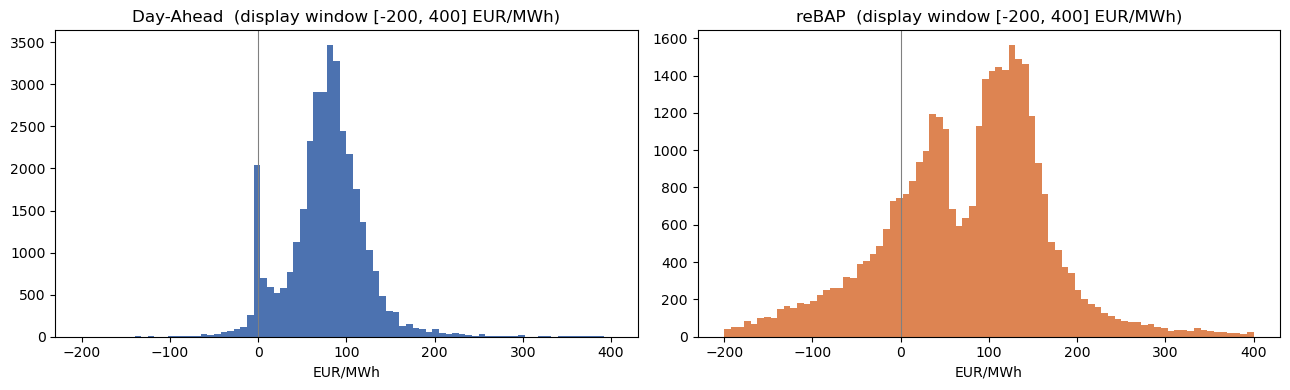

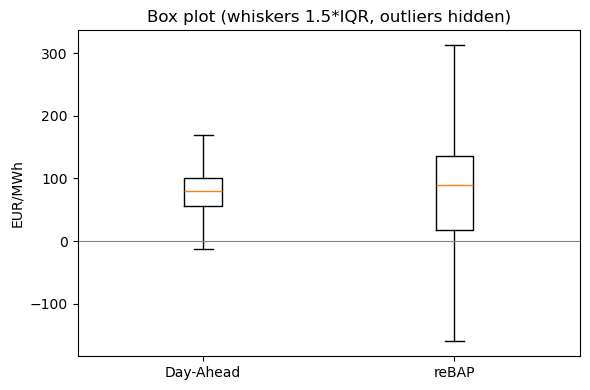

Day-Ahead  negative:  1828 (5.20%) | >150: 1444 | >300: 164 | >500: 60
reBAP      negative:  6962 (19.81%) | >150: 6134 | >300: 824 | >500: 296


In [3]:
qs = [0, .01, .05, .25, .50, .75, .95, .99, 1]
qt = pd.DataFrame({
    "Day-Ahead": [da[DAP].quantile(q) for q in qs],
    "reBAP":     [im[IMP].quantile(q) for q in qs],
}, index=[f"{int(q*100)}%" for q in qs])
qt.loc["mean"] = [da[DAP].mean(), im[IMP].mean()]
qt.loc["std"]  = [da[DAP].std(),  im[IMP].std()]
qt.loc["MAD (median)"] = [(da[DAP] - da[DAP].median()).abs().median(),
                          (im[IMP] - im[IMP].median()).abs().median()]
print("Quantile / spread table [EUR/MWh]")
print(qt.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, (lab, x, c) in zip(ax, [("Day-Ahead", da[DAP], "#4C72B0"), ("reBAP", im[IMP], "#DD8452")]):
    a.hist(x, bins=80, range=(-200, 400), color=c)
    a.axvline(0, color="grey", lw=.8)
    a.set_title(f"{lab}  (display window [-200, 400] EUR/MWh)")
    a.set_xlabel("EUR/MWh")
plt.tight_layout(); plt.show()

fig, a = plt.subplots(figsize=(6, 4))
a.boxplot([da[DAP], im[IMP]], labels=["Day-Ahead", "reBAP"], showfliers=False)
a.axhline(0, color="grey", lw=.8); a.set_ylabel("EUR/MWh")
a.set_title("Box plot (whiskers 1.5*IQR, outliers hidden)")
plt.tight_layout(); plt.show()

for lab, x in [("Day-Ahead", da[DAP]), ("reBAP", im[IMP])]:
    print(f"{lab:10s} negative: {int((x<0).sum()):5d} ({100*(x<0).mean():.2f}%) | "
          f">150: {int((x>150).sum())} | >300: {int((x>300).sum())} | >500: {int((x>500).sum())}")

**What the distributions show**

- **Day-Ahead** is roughly bell-shaped around a median of **79.59**, IQR **55.56 to 101.34**, with a
  moderate right tail (99 % = 224.92) and a thin left tail into negatives.
- **reBAP** is far wider and heavier-tailed: median **89.96** but IQR **17.16 to 135.62** (2.6x the
  Day-Ahead IQR), MAD **56.52** vs **22.78**, and tails reaching **-5,734** and **+15,000**
  (the latter a hard cap). It also has far more mass below zero.
- **Negative prices:** Day-Ahead is negative in **5.20 %** of quarter-hours, reBAP in **19.81 %** -
  roughly four times as often.

## 3. Extreme prices

In [4]:
def extremes(df, col, n=5):
    top = df.nlargest(n, col)[["t", col]]
    bot = df.nsmallest(n, col)[["t", col]]
    return top, bot

for lab, df, col in [("DAY-AHEAD", da, DAP), ("reBAP", im, IMP)]:
    top, bot = extremes(df, col)
    print(f"\n=== {lab} - highest quarter-hours ===")
    print(top.to_string(index=False))
    print(f"=== {lab} - lowest quarter-hours ===")
    print(bot.to_string(index=False))

print("\n--- worst / best days (daily mean) ---")
dmean = pd.DataFrame({"DA": da.groupby(da.t.dt.date)[DAP].mean(),
                      "reBAP": im.groupby(im.t.dt.date)[IMP].mean()})
print("DA highest days   :", {str(k): round(v, 2) for k, v in dmean["DA"].nlargest(4).items()})
print("DA lowest days    :", {str(k): round(v, 2) for k, v in dmean["DA"].nsmallest(4).items()})
print("reBAP highest days:", {str(k): round(v, 2) for k, v in dmean["reBAP"].nlargest(4).items()})
print("reBAP lowest days :", {str(k): round(v, 2) for k, v in dmean["reBAP"].nsmallest(4).items()})


=== DAY-AHEAD - highest quarter-hours ===
                  t  day_ahead_price_eur_mwh
2024-12-12 17:00:00                   936.28
2024-12-12 17:15:00                   936.28
2024-12-12 17:30:00                   936.28
2024-12-12 17:45:00                   936.28
2024-11-06 17:00:00                   820.11
=== DAY-AHEAD - lowest quarter-hours ===
                  t  day_ahead_price_eur_mwh
2024-05-12 13:00:00                  -135.45
2024-05-12 13:15:00                  -135.45
2024-05-12 13:30:00                  -135.45
2024-05-12 13:45:00                  -135.45
2024-05-12 14:00:00                  -132.85

=== reBAP - highest quarter-hours ===
                  t  imbalance_price_eur_mwh
2024-06-03 09:00:00                14,999.99
2024-06-03 08:00:00                14,129.27
2024-08-26 19:45:00                13,194.36
2024-06-03 09:30:00                12,125.64
2024-06-03 09:45:00                11,871.49
=== reBAP - lowest quarter-hours ===
                  t  imbalance

**Extreme values**

- **Day-Ahead high:** **936.28 EUR/MWh** on **12 Dec 2024, 17:00-18:00** (daily mean 395.34) -
  the annual peak, a cold, low-wind December evening. Next highest days 11 Dec (266.54) and
  6 Nov (231.09).
- **Day-Ahead low:** **-135.45 EUR/MWh** on **12 May 2024, 13:00-14:00** (a sunny Sunday midday,
  daily mean 1.78).
- **reBAP high:** **14,999.99 EUR/MWh** on **3 Jun 2024, 09:00** (capped; 08:00 was 14,129.27),
  and **13,194.36** on 26 Aug 2024, 19:45 - short, sharp system-shortage events. Highest day
  3 Jun (mean 1,218.02).
- **reBAP low:** **-5,734.46 EUR/MWh** on **7 Apr 2024, 14:15**, then **-4,599.81** on 10 Apr,
  **-3,518.42** on 28 Jun - all sunny spring/summer afternoons with a long system.

## 4. Is reBAP more variable than Day-Ahead?

dispersion measure   Day-Ahead      reBAP     ratio
  std                   52.72     282.66    5.36x
  IQR                   45.78     118.47    2.59x
  MAD                   22.78      56.52    2.48x
  rng                 1071.73   20734.45   19.35x

corr(Day-Ahead, reBAP)          : 0.234
spread reBAP - Day-Ahead        : mean 7.26  std 275.15  mean|spread| 84.79
quarter-hours where the two have opposite sign: 18.98%


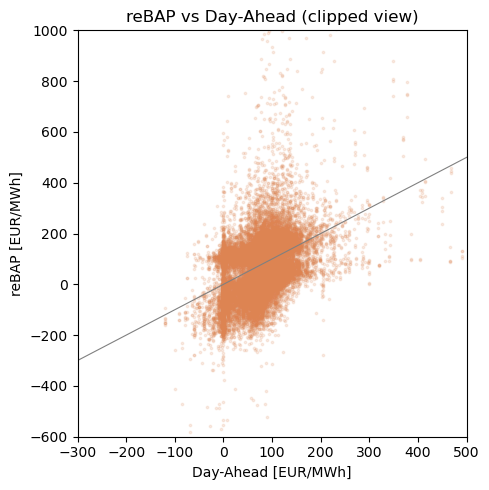

In [5]:
def spread_stats(x):
    return dict(std=x.std(), IQR=x.quantile(.75) - x.quantile(.25),
               MAD=(x - x.median()).abs().median(), rng=x.max() - x.min())

sda, sim = spread_stats(da[DAP]), spread_stats(im[IMP])
print("dispersion measure   Day-Ahead      reBAP     ratio")
for k in ["std", "IQR", "MAD", "rng"]:
    print(f"  {k:5s}            {sda[k]:10.2f} {sim[k]:10.2f}   {sim[k]/sda[k]:5.2f}x")

print(f"\ncorr(Day-Ahead, reBAP)          : {m[DAP].corr(m[IMP]):.3f}")
print(f"spread reBAP - Day-Ahead        : mean {m.spread.mean():.2f}  std {m.spread.std():.2f}  "
      f"mean|spread| {m.spread.abs().mean():.2f}")
print(f"quarter-hours where the two have opposite sign: {100*((np.sign(m[IMP])!=np.sign(m[DAP]))).mean():.2f}%")

fig, a = plt.subplots(figsize=(5, 5))
a.scatter(m[DAP], m[IMP], s=3, alpha=.15, color="#DD8452")
lim = [-300, 500]; a.plot(lim, lim, color="grey", lw=.8)
a.set_xlim(lim); a.set_ylim(-600, 1000)
a.set_xlabel("Day-Ahead [EUR/MWh]"); a.set_ylabel("reBAP [EUR/MWh]")
a.set_title("reBAP vs Day-Ahead (clipped view)")
plt.tight_layout(); plt.show()

**Yes - reBAP is far more variable.** Its standard deviation is **5.36x** the Day-Ahead value
(282.66 vs 52.72), its IQR **2.59x**, its MAD **2.48x**, and its realised range about **19x** wider
(-5,734 to +15,000 vs -135 to +936). It is also only weakly linked to Day-Ahead
(**correlation 0.23**): the average reBAP sits just **7.26 EUR/MWh** above Day-Ahead, but the
quarter-hourly gap has a standard deviation of **275.15** and a mean absolute size of **84.79**,
and in **18.98 %** of quarter-hours the two prices have opposite signs. reBAP is therefore not an
amplified Day-Ahead - it carries its own, much larger balancing risk.

## 5. One market episode for the main project

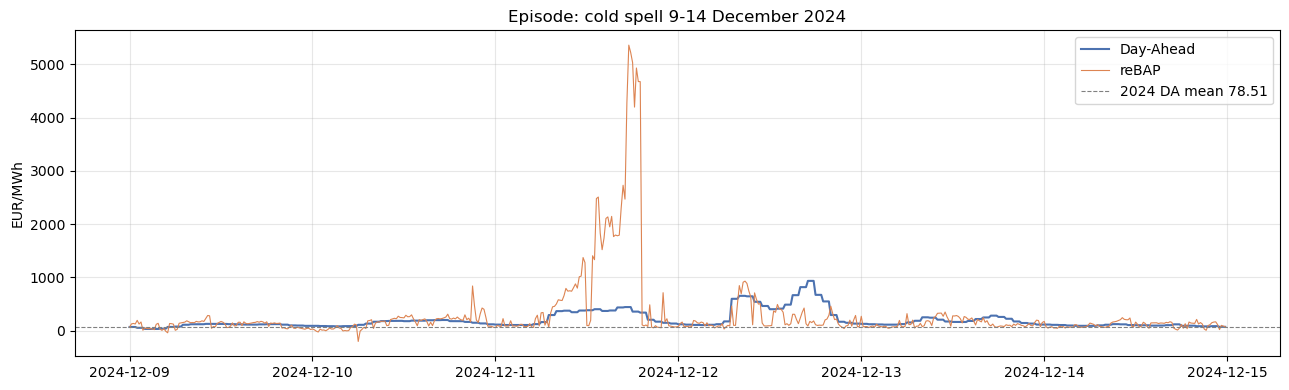

9-14 Dec 2024:
  Day-Ahead: max 936.28, mean 198.52, quarter-hours > 300: 100 (25.0 h)
  reBAP    : max 5359.16, min -200.27, mean 293.28
  12 Dec  : DA mean 395.34, DA max 936.28, reBAP mean 233.12

contrast 3 Jun 2024 (imbalance-only spike): DA mean 117.14 (max 215.28), reBAP mean 1218.02 (max 14999.99)


In [6]:
ep = m[(m.t >= "2024-12-09") & (m.t < "2024-12-15")]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ep.t, ep[DAP], label="Day-Ahead", color="#4C72B0")
ax.plot(ep.t, ep[IMP], label="reBAP", color="#DD8452", lw=.8)
ax.axhline(da[DAP].mean(), color="grey", ls="--", lw=.8, label=f"2024 DA mean {da[DAP].mean():.2f}")
ax.set_ylabel("EUR/MWh"); ax.set_title("Episode: cold spell 9-14 December 2024")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("9-14 Dec 2024:")
print(f"  Day-Ahead: max {ep[DAP].max():.2f}, mean {ep[DAP].mean():.2f}, "
      f"quarter-hours > 300: {int((ep[DAP] > 300).sum())} ({(ep[DAP] > 300).sum()/4:.1f} h)")
print(f"  reBAP    : max {ep[IMP].max():.2f}, min {ep[IMP].min():.2f}, mean {ep[IMP].mean():.2f}")
peak_day = ep[ep.t.dt.date == pd.Timestamp('2024-12-12').date()]
print(f"  12 Dec  : DA mean {peak_day[DAP].mean():.2f}, DA max {peak_day[DAP].max():.2f}, "
      f"reBAP mean {peak_day[IMP].mean():.2f}")

# contrast: the pure imbalance blow-out on 3 Jun
jun = m[m.t.dt.date == pd.Timestamp('2024-06-03').date()]
print(f"\ncontrast 3 Jun 2024 (imbalance-only spike): DA mean {jun[DAP].mean():.2f} (max {jun[DAP].max():.2f}), "
      f"reBAP mean {jun[IMP].mean():.2f} (max {jun[IMP].max():.2f})")

**Chosen episode: the cold spell of 9-14 December 2024.** Over these six days Day-Ahead averaged **198.52 EUR/MWh** - more than double the 2024 mean of 78.51 - with **25 hours above 300 EUR/MWh** and a peak of **936.28** on the evening of 12 December; reBAP was elevated alongside it (daily mean **233.12** on 12 December, six-day mean 293.28). This is a *sustained, system-wide* high-price period, unlike the isolated reBAP blow-outs such as **3 June 2024**, where reBAP hit the 15,000 cap in the morning while Day-Ahead stayed an order of magnitude lower (daily mean 117.14, max 215.28). It is the natural candidate for the severe-price-event analysis in Stage 7: it lasts long enough that an unhedged position would accumulate a large cash outflow, and it lets us contrast how the UNHEDGED, COARSE_CAL and GRANULAR strategies would have been exposed.

## Close the briefing

The three review questions (information available ex ante vs. during delivery; data checks performed; assumptions still missing for a real portfolio) are answered in the dedicated folder
`data briefing/Close the briefing/` - `close_the_briefing_EN.md`.